In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [5]:
feature_df.shape

(2280, 2729)

In [6]:
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 32), (64, 32, 32)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.001, 0.1],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [16, 32, 64],
    'max_iter': [1000],
}

xgb_param_grid = {
    'n_estimators': [00],
    'max_depth': [7],
    'learning_rate': [0.01],
    'gamma': [0]
}

lightgbm_param_grid = {
    'n_estimators': [100, ],
    'learning_rate': [0.01],
    'max_depth': [3],
    'num_leaves': [15],
    'subsample': [0.8],
    'verbose': [-1]
}

In [7]:
feature_df.fillna(-1, inplace=True)

In [8]:
run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: SklearnWrapper(XGBClassifier, **params),
    model_param_grid=xgb_param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='XGBClassifier',
    key_columns=TRAINGING_CONFIG['key_columns'],
)


Training XGBClassifier on home_goals with param grid: {'n_estimators': [0], 'max_depth': [7], 'learning_rate': [0.01], 'gamma': [0]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'n_estimators': 0, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0}
Training fold 2/5 with params: {'n_estimators': 0, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0}
Training fold 3/5 with params: {'n_estimators': 0, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0}


/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

Training fold 4/5 with params: {'n_estimators': 0, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0}
Training fold 5/5 with params: {'n_estimators': 0, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0}


/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

{'home_goals_train_accuracy': 0.2511598440545809, 'home_goals_train_precision': 0.030115876110028156, 'home_goals_valid_accuracy': 0.24853801169590645, 'home_goals_valid_precision': 0.031008075744917846, 'home_goals_test_accuracy': 0.17543859649122806, 'home_goals_test_precision': 0.02506265664160401, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 0.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 0.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 0.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3_accuracy': 0.0, 'home_goals_train_gt_3_accuracy_std': 0.0, 'home_goals_train_gt_3_precision': 0.0, 'home_goals_train_gt_3_precision_std': 0.0, 'home_goals_train_gt_4_accura

/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

Training fold 5/5 with params: {'n_estimators': 0, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0}


/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'away_goals_train_accuracy': 0.3212962962962963, 'away_goals_train_precision': 0.03859165661066245, 'away_goals_valid_accuracy': 0.3198830409356725, 'away_goals_valid_precision': 0.04365079365079365, 'away_goals_test_accuracy': 0.2631578947368421, 'away_goals_test_precision': 0.03759398496240601, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 0.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 0.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 0.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 0.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt_3_accuracy': 0.0, 'away_goals_train_gt_3_accuracy_std': 0.0, 'away_goals_train_gt_3_precision': 0.0, 'away_goals_train_gt_3_precision_std': 0.0, 'away_goals_train_gt_4_accuracy':

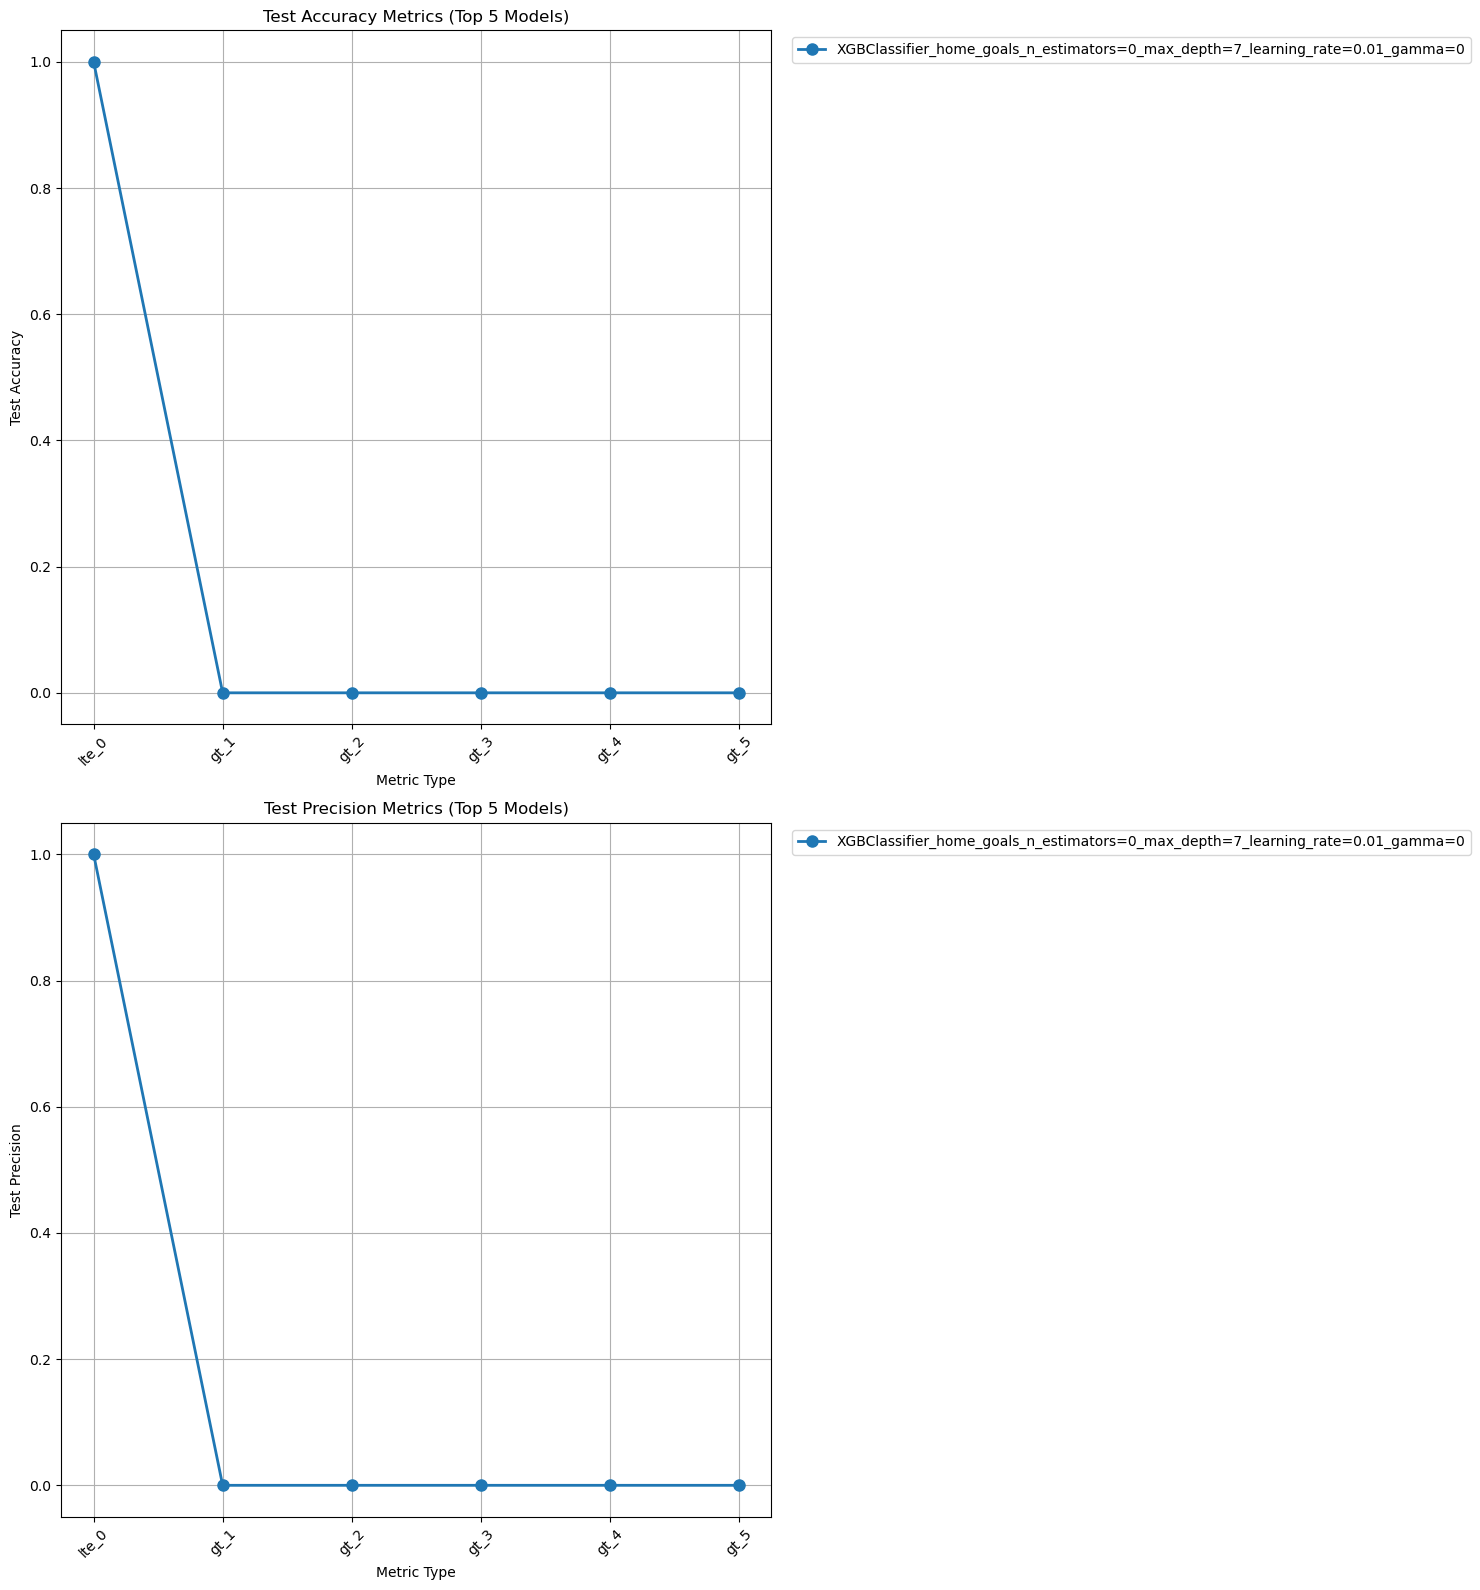

In [9]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="XGBClassifier",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [10]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="XBGClassifier_home_goals_n_estimators=200_max_depth=7_learning_rate=0.01_gamma=0",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

No run found with name 'XBGClassifier_home_goals_n_estimators=200_max_depth=7_learning_rate=0.01_gamma=0'.


In [11]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="XBGClassifier",
                              model_param={'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'XBGClassifier' and params.n_estimators: '200' and params.max_depth: '7' and params.learning_rate: '0.01' and params.gamma: '0'


MlflowException: Invalid clause(s) in filter string: 'params.n_estimators', ':', ''200'', 'params.max_depth', ':', ''7'', 'params.learning_rate', ':', ''0.01'', 'params.gamma', ':', ''0''